In [51]:
import torch
import numpy as np
from gensim.models import KeyedVectors
import torch.nn as nn
import os
import gensim.downloader as api

try:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # 1. 모델 로드
    print("사전 학습 임베딩 로드 중...")
    word_vectors = api.load('glove-twitter-25')

    word2vec_dim = word_vectors.vector_size
    # vocab_size가 실제 word_to_index 크기와 일치하는지 재확인
    current_vocab_size = len(word_to_index)
    embedding_matrix = np.zeros((current_vocab_size, word2vec_dim))

    for i in range(current_vocab_size):
        word = index_to_word.get(i)
        if word in word_vectors:
            embedding_matrix[i] = word_vectors[word]
        else:
            embedding_matrix[i] = np.random.randn(word2vec_dim)

    class ImprovedLSTM(nn.Module):
        def __init__(self, vocab_size, embedding_dim, hidden_dim, pretrained_weights):
            super(ImprovedLSTM, self).__init__()
            # vocab_size 불일치로 인한 CUDA assert 방지를 위해 명시적으로 크기 지정
            self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(pretrained_weights), padding_idx=0, freeze=False)
            self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)
            self.dropout = nn.Dropout(0.5)
            self.fc = nn.Linear(hidden_dim * 2, 1)
            self.sigmoid = nn.Sigmoid()

        def forward(self, x):
            x = self.embedding(x)
            output, (hidden, _) = self.lstm(x)
            x = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
            x = self.dropout(x)
            x = self.fc(x)
            return self.sigmoid(x)

    # 2. 모델 생성 (반드시 current_vocab_size 사용)
    final_model = ImprovedLSTM(current_vocab_size, word2vec_dim, 256, embedding_matrix)
    final_model.to(device)

    print("개선된 Bidirectional LSTM 모델 학습 시작...")
    # 입력 데이터 텐서의 인덱스가 vocab_size 범위 내에 있는지 확인하는 로직이 train_model 내부에 있어야 함
    final_history = train_model(final_model, train_loader, val_loader, epochs=5, lr=0.001)
    plot_history(final_history)

except Exception as e:
    print(f"에러 발생: {e}")

Using device: cuda
사전 학습 임베딩 로드 중...
에러 발생: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



In [1]:
!mkdir -p ~/work/sentiment_classification

# 실습에 활용할 수 있도록 라이브러리 설치 및 다운그레이드를 수행합니다
!pip install gensim==4.3.2
!conda install scipy==1.12.0 numpy==1.26.3 -y

/bin/bash: line 1: conda: command not found


In [2]:
# 처리해야 할 문장을 파이썬 리스트에 옮겨 담았습니다.
sentences=['i feel hungry', 'i eat lunch', 'now i feel happy']

# 파이썬 split() 메소드를 이용해 단어 단위로 문장을 쪼개 봅니다.
word_list = 'i feel hungry'.split()
print(word_list)

['i', 'feel', 'hungry']


In [3]:
index_to_word={}  # 빈 딕셔너리를 만들어서

# 단어들을 하나씩 채워 봅니다. 채우는 순서는 일단 임의로 하였습니다. 그러나 사실 순서는 중요하지 않습니다.
# <BOS>, <PAD>, <UNK>는 관례적으로 딕셔너리 맨 앞에 넣어줍니다.
index_to_word[0]='<PAD>'  # 패딩용 단어
index_to_word[1]='<BOS>'  # 문장의 시작지점
index_to_word[2]='<UNK>'  # 사전에 없는(Unknown) 단어
index_to_word[3]='i'
index_to_word[4]='feel'
index_to_word[5]='hungry'
index_to_word[6]='eat'
index_to_word[7]='lunch'
index_to_word[8]='now'
index_to_word[9]='happy'

print(index_to_word)

{0: '<PAD>', 1: '<BOS>', 2: '<UNK>', 3: 'i', 4: 'feel', 5: 'hungry', 6: 'eat', 7: 'lunch', 8: 'now', 9: 'happy'}


In [4]:
word_to_index={word:index for index, word in index_to_word.items()}
print(word_to_index)

{'<PAD>': 0, '<BOS>': 1, '<UNK>': 2, 'i': 3, 'feel': 4, 'hungry': 5, 'eat': 6, 'lunch': 7, 'now': 8, 'happy': 9}


In [5]:
print(word_to_index['feel'])  # 단어 'feel'은 숫자 인덱스 4로 바뀝니다.

4


In [6]:
# 문장 1개를 활용할 딕셔너리와 함께 주면, 단어 인덱스 리스트로 변환해 주는 함수를 만들어 봅시다.
# 단, 모든 문장은 <BOS>로 시작하는 것으로 합니다.
def get_encoded_sentence(sentence, word_to_index):
    return [word_to_index['<BOS>']]+[word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in sentence.split()]

print(get_encoded_sentence('i eat lunch', word_to_index))

[1, 3, 6, 7]


In [7]:
# 여러 개의 문장 리스트를 한꺼번에 숫자 텐서로 encode해 주는 함수입니다.
def get_encoded_sentences(sentences, word_to_index):
    return [get_encoded_sentence(sentence, word_to_index) for sentence in sentences]

# sentences=['i feel hungry', 'i eat lunch', 'now i feel happy'] 가 아래와 같이 변환됩니다.
encoded_sentences = get_encoded_sentences(sentences, word_to_index)
print(encoded_sentences)

[[1, 3, 4, 5], [1, 3, 6, 7], [1, 8, 3, 4, 9]]


In [8]:
# 숫자 벡터로 encode된 문장을 원래대로 decode하는 함수입니다.
def get_decoded_sentence(encoded_sentence, index_to_word):
    return ' '.join(index_to_word[index] if index in index_to_word else '<UNK>' for index in encoded_sentence[1:])  #[1:]를 통해 <BOS>를 제외

print(get_decoded_sentence([1, 3, 4, 5], index_to_word))

i feel hungry


In [9]:
# 여러 개의 숫자 벡터로 encode된 문장을 한꺼번에 원래대로 decode하는 함수입니다.
def get_decoded_sentences(encoded_sentences, index_to_word):
    return [get_decoded_sentence(encoded_sentence, index_to_word) for encoded_sentence in encoded_sentences]

# encoded_sentences=[[1, 3, 4, 5], [1, 3, 6, 7], [1, 8, 3, 4, 9]] 가 아래와 같이 변환됩니다.
print(get_decoded_sentences(encoded_sentences, index_to_word))

['i feel hungry', 'i eat lunch', 'now i feel happy']


In [50]:
import torch
import torch.nn as nn

# word_to_index에서 패딩 토큰 확인 (load_data 결과에 따라 ''를 사용하거나 정의 필요)
pad_token = '<PAD>'
if pad_token not in word_to_index:
    # load_data의 vocab 구성상 0번 인덱스가 보통 패딩 역할을 함
    word_to_index[pad_token] = 0

vocab_size = len(word_to_index)
word_vector_dim = 4

# KeyError 방지를 위해 get() 또는 직접 확인 후 생성
embedding = nn.Embedding(vocab_size, word_vector_dim, padding_idx=word_to_index[pad_token])

encoded_sentences = get_encoded_sentences(sentences, word_to_index)
maxlen = 5
padded_sentences = [sentence + [word_to_index[pad_token]] * (maxlen - len(sentence)) if len(sentence) < maxlen else sentence[:maxlen] for sentence in encoded_sentences]

raw_inputs = torch.tensor(padded_sentences, dtype=torch.long)
output = embedding(raw_inputs)
print(output)

KeyError: '<BOS>'

In [52]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. 특수 토큰 보강 및 사전 업데이트
# 기존 word_to_index가 3번부터 단어를 가지고 있으므로 0, 1, 2에 특수 토큰 할당
special_tokens = {'<PAD>': 0, '<BOS>': 1, '<UNK>': 2}
for token, idx in special_tokens.items():
    if token not in word_to_index:
        word_to_index[token] = idx

# index_to_word 업데이트
index_to_word = {index: word for word, index in word_to_index.items()}
current_vocab_size = len(word_to_index)

# 2. 사전 학습 임베딩 매핑 (glove-twitter-25 사용)
import gensim.downloader as api
print("사전 학습 임베딩 로드 중...")
word_vectors = api.load('glove-twitter-25')
word2vec_dim = word_vectors.vector_size

embedding_matrix = np.zeros((current_vocab_size, word2vec_dim))
for i in range(current_vocab_size):
    word = index_to_word.get(i)
    if word in word_vectors:
        embedding_matrix[i] = word_vectors[word]
    else:
        embedding_matrix[i] = np.random.randn(word2vec_dim)

# 3. 데이터 재인코딩 및 패딩 (에러 방지용)
def get_fixed_encoded_sentences(sentences_list, word_to_index):
    encoded = []
    for tokens in sentences_list:
        # 이미 토큰화된 리스트이므로 바로 인덱싱
        line = [word_to_index['<BOS>']] + [word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in tokens]
        encoded.append(line)
    return encoded

def get_padded_tensor(encoded_list, max_len):
    padded = []
    for seq in encoded_list:
        if len(seq) < max_len:
            padded.append(seq + [0] * (max_len - len(seq)))
        else:
            padded.append(seq[:max_len])
    return torch.tensor(padded, dtype=torch.long)

# 전역 변수 X_train(토큰 리스트)을 사용하여 텐서 생성
x_train_final = get_padded_tensor(get_fixed_encoded_sentences(X_train, word_to_index), max_len=41)
x_test_final = get_padded_tensor(get_fixed_encoded_sentences(X_test, word_to_index), max_len=41)
y_train_final = torch.tensor(y_train, dtype=torch.float32)
y_test_final = torch.tensor(y_test, dtype=torch.float32)

# 4. 모델 정의
class FinalImprovedLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, weights):
        super(FinalImprovedLSTM, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(weights), padding_idx=0, freeze=False)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        x = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        x = self.dropout(x)
        x = self.fc(x)
        return self.sigmoid(x)

# 5. 학습 루프 및 실행
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
final_model = FinalImprovedLSTM(current_vocab_size, word2vec_dim, 256, embedding_matrix).to(device)

train_loader = DataLoader(TensorDataset(x_train_final[20000:], y_train_final[20000:]), batch_size=512, shuffle=True)
val_loader = DataLoader(TensorDataset(x_train_final[:20000], y_train_final[:20000]), batch_size=512)

print(f"최종 모델 학습 시작... (Vocab Size: {current_vocab_size})")
final_history = train_model(final_model, train_loader, val_loader, epochs=10, lr=0.001)
plot_history(final_history)

사전 학습 임베딩 로드 중...


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [55]:
# 아래 코드는 그대로 실행하시면 에러가 발생할 것입니다.

import torch
import torch.nn as nn
import numpy as np
import os

vocab_size = len(word_to_index)  # 위 예시에서 딕셔너리에 포함된 단어 개수는 10
word_vector_dim = 4    # 위 그림과 같이 4차원의 워드 벡터를 가정합니다.

embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=word_vector_dim, padding_idx=0)

# 숫자로 변환된 텍스트 데이터 [[1, 3, 4, 5], [1, 3, 6, 7], [1, 8, 3, 4, 9]] 에 Embedding 레이어를 적용합니다.
import torch.nn.functional as F

raw_inputs = [torch.tensor(sentence, dtype=torch.long) for sentence in raw_inputs]
raw_inputs = torch.nn.utils.rnn.pad_sequence(raw_inputs, batch_first=True, padding_value=word_to_index['<PAD>'])
print(raw_inputs)

tensor([[1, 3, 4, 5, 0],
        [1, 3, 6, 7, 0],
        [1, 8, 3, 4, 9]])


/tmp/ipykernel_9201/3135870960.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  raw_inputs = [torch.tensor(sentence, dtype=torch.long) for sentence in raw_inputs]


In [56]:
vocab_size = len(word_to_index)   # 위 예시에서 딕셔너리에 포함된 단어 개수는 10
word_vector_dim = 4   # 그림과 같이 4차원의 워드 벡터를 가정합니다.

embedding = nn.Embedding(vocab_size, word_vector_dim, padding_idx=word_to_index['<PAD>'])

# nn.Embedding를 통해 word vector를 모두 일정 길이로 맞춰주어야
# embedding 레이어의 input이 될 수 있음에 주의해 주세요.
encoded_sentences = get_encoded_sentences(sentences, word_to_index)
maxlen = 5
padded_sentences = [sentence + [word_to_index['<PAD>']] * (maxlen - len(sentence)) if len(sentence) < maxlen else sentence[:maxlen] for sentence in encoded_sentences]

raw_inputs = torch.tensor(padded_sentences, dtype=torch.long)
output = embedding(raw_inputs)
print(output)

tensor([[[-0.5117, -0.4498,  0.1858,  1.1123],
         [-0.5349, -1.5418, -1.7617,  0.6958],
         [-0.6515, -0.9968, -0.0450,  0.0799],
         [-0.6515, -0.9968, -0.0450,  0.0799],
         [ 0.0000,  0.0000,  0.0000,  0.0000]],

        [[-0.5117, -0.4498,  0.1858,  1.1123],
         [-0.5349, -1.5418, -1.7617,  0.6958],
         [-0.6515, -0.9968, -0.0450,  0.0799],
         [-0.6515, -0.9968, -0.0450,  0.0799],
         [ 0.0000,  0.0000,  0.0000,  0.0000]],

        [[-0.5117, -0.4498,  0.1858,  1.1123],
         [-0.6515, -0.9968, -0.0450,  0.0799],
         [-0.5349, -1.5418, -1.7617,  0.6958],
         [-0.6515, -0.9968, -0.0450,  0.0799],
         [-0.6515, -0.9968, -0.0450,  0.0799]]], grad_fn=<EmbeddingBackward0>)


In [57]:
class Model_2(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(Model_2, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.conv1 = nn.Conv1d(word_vector_dim, 16, kernel_size=7)
        self.conv2 = nn.Conv1d(16, 16, kernel_size=7)
        self.pool = nn.MaxPool1d(5)
        self.global_max_pooling = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(16, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)    # 최종 출력은 긍정/부정을 나타내는 1dim 입니다.
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.global_max_pooling(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

vocab_size = 10    # 어휘 사전의 크기입니다(10개의 단어)
word_vector_dim = 4   # 단어 하나를 표현하는 임베딩 벡터의 차원 수입니다.
model = Model_2(vocab_size, word_vector_dim)

print(model)

Model_2(
  (embedding): Embedding(10, 4)
  (conv1): Conv1d(4, 16, kernel_size=(7,), stride=(1,))
  (conv2): Conv1d(16, 16, kernel_size=(7,), stride=(1,))
  (pool): MaxPool1d(kernel_size=5, stride=5, padding=0, dilation=1, ceil_mode=False)
  (global_max_pooling): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=16, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [58]:
class Model_3(nn.Module):
    def __init__(self, vocab_size, word_vector_dim):
        super(Model_3, self).__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim)
        self.global_max_pooling = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(word_vector_dim, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)    # 최종 출력은 긍정/부정을 나타내는 1dim 입니다.
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.global_max_pooling(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

vocab_size = 10   # 어휘 사전의 크기입니다(10개의 단어)
word_vector_dim = 4   # 단어 하나를 표현하는 임베딩 벡터의 차원 수입니다.
model = Model_3(vocab_size, word_vector_dim)

print(model)

Model_3(
  (embedding): Embedding(10, 4)
  (global_max_pooling): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once your Google Drive is mounted, you can load your data. For example, if you have a CSV file named `my_data.csv` in your Drive, you can load it using pandas:

In [60]:
# 원본 IMDb 데이터셋 다운로드
import tensorflow as tf

imdb = tf.keras.datasets.imdb

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

print(f"훈련 샘플 개수: {len(x_train)}, 테스트 개수: {len(x_test)}")

훈련 샘플 개수: 25000, 테스트 개수: 25000


In [61]:
print(x_train[0])  # 1번째 리뷰데이터
print('라벨: ', y_train[0])  # 1번째 리뷰데이터의 라벨
print('1번째 리뷰 문장 길이: ', len(x_train[0]))
print('2번째 리뷰 문장 길이: ', len(x_train[1]))

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
라벨:  1
1번째 리뷰 문장 길이:  218
2번째 리뷰 문장 길이:  189


In [62]:
word_to_index = imdb.get_word_index()
# word_to_index = np.load(data_dir + 'imdb_word_to_index.pickle', allow_pickle=True)
index_to_word = {index:word for word, index in word_to_index.items()}
print(index_to_word[1])     # 'the' 가 출력됩니다.
print(word_to_index['the'])  # 1 이 출력됩니다.

the
1


In [63]:
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
!mv ratings_*.txt ~/work/sentiment_classification/

--2026-08-11 05:42:03--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14628807 (14M) [text/plain]
Saving to: ‘ratings_train.txt’

ratings_train.txt   100%[===================>]  13.95M  --.-KB/s    in 0.07s   

2026-08-11 05:42:04 (189 MB/s) - ‘ratings_train.txt’ saved [14628807/14628807]

--2026-08-11 05:42:04--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4893335 (4.7M) [application/octet-

In [64]:
!pip install konlpy
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh

Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 138 (delta 26), reused 22 (delta 8), pack-reused 91 (from 1)
Receiving objects: 100% (138/138), 1.72 MiB | 18.11 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/content/Mecab-ko-for-Google-Colab/Mecab-ko-for-Google-Colab
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-08-11 05:42:17--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 104.192.142.26, 104.192.142.25, 104.192.142.24, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.26|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-08-11 05:42:17 ERROR 404: Not Found.

Done
Unpacking mecab-0.996-ko-0.9.2.tar.gz.......
Done
C

In [65]:
!python --version

Python 3.12.13


In [66]:
!pip install gensim==4.3.2

In [67]:
# 의존성 연결을 위해 다운그레이드를 진행합니다.
!pip install scipy==1.12.0 numpy==1.26.3

In [26]:
import pandas
import konlpy
import gensim

print(pandas.__version__)
print(konlpy.__version__)
print(gensim.__version__)

2.2.2
0.6.0
4.3.2


In [68]:
import pandas as pd
import os

# 데이터를 읽어봅시다.
train_data = pd.read_table(os.getenv("HOME") + '/work/sentiment_classification/ratings_train.txt')
test_data = pd.read_table(os.getenv("HOME") + '/work/sentiment_classification/ratings_test.txt')

train_data.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [69]:
from konlpy.tag import Mecab
import numpy as np
from collections import Counter

tokenizer = Mecab()
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

def load_data(train_data, test_data, num_words=10000):
    train_data.drop_duplicates(subset=['document'], inplace=True)
    train_data = train_data.dropna(how = 'any')
    test_data.drop_duplicates(subset=['document'], inplace=True)
    test_data = test_data.dropna(how = 'any')

    X_train = []
    for sentence in train_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_train.append(temp_X)

    X_test = []
    for sentence in test_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_test.append(temp_X)

    words = np.concatenate(X_train).tolist()
    counter = Counter(words)
    counter = counter.most_common(10000-4)
    vocab = ['', '', '', ''] + [key for key, _ in counter]
    word_to_index = {word:index for index, word in enumerate(vocab)}

    def wordlist_to_indexlist(wordlist):
        return [word_to_index[word] if word in word_to_index else word_to_index[''] for word in wordlist]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return X_train, np.array(list(train_data['label'])), X_test, np.array(list(test_data['label'])), word_to_index

X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)

In [70]:
index_to_word = {index:word for word, index in word_to_index.items()}

In [71]:
# 문장 1개를 활용할 딕셔너리와 함께 주면, 단어 인덱스 리스트 벡터로 변환해 주는 함수입니다.
# 단, 모든 문장은 <BOS>로 시작하는 것으로 합니다.
def get_encoded_sentence(sentence, word_to_index):
    return [word_to_index['<BOS>']]+[word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in sentence.split()]

# 여러 개의 문장 리스트를 한꺼번에 단어 인덱스 리스트 벡터로 encode해 주는 함수입니다.
def get_encoded_sentences(sentences, word_to_index):
    return [get_encoded_sentence(sentence, word_to_index) for sentence in sentences]

# 숫자 벡터로 encode된 문장을 원래대로 decode하는 함수입니다.
def get_decoded_sentence(encoded_sentence, index_to_word):
    return ' '.join(index_to_word[index] if index in index_to_word else '<UNK>' for index in encoded_sentence[1:])  #[1:]를 통해 <BOS>를 제외

# 여러 개의 숫자 벡터로 encode된 문장을 한꺼번에 원래대로 decode하는 함수입니다.
def get_decoded_sentences(encoded_sentences, index_to_word):
    return [get_decoded_sentence(encoded_sentence, index_to_word) for encoded_sentence in encoded_sentences]

### 3) 모델 구성을 위한 데이터 분석 및 가공

데이터셋 내의 문장 길이 분포를 확인하고, 적절한 최대 문장 길이를 결정합니다.

In [72]:
import matplotlib.pyplot as plt

total_data_text = list(X_train) + list(X_test)
# 문장길이 분포 확인
num_tokens = [len(tokens) for tokens in total_data_text]
num_tokens = np.array(num_tokens)

print('문장길이 평균 : ', np.mean(num_tokens))
print('문장길이 최대 : ', np.max(num_tokens))
print('문장길이 표준편차 : ', np.std(num_tokens))

# 최대 길이를 (평균 + 2*표준편차)로 설정
max_len = int(np.mean(num_tokens) + 2 * np.std(num_tokens))
print('설정된 max_len : ', max_len)
print(f'전체 문장의 {np.sum(num_tokens < max_len) / len(num_tokens) * 100:.2f}%가 max_len 설정 내에 포함됩니다.')

문장길이 평균 :  15.971004254142798
문장길이 최대 :  116
문장길이 표준편차 :  12.844081305622485
설정된 max_len :  41
전체 문장의 93.07%가 max_len 설정 내에 포함됩니다.


PyTorch의 `pad_sequence`를 사용하여 패딩을 추가합니다. `word_to_index['<PAD>']`가 0임을 고려하여 처리합니다.

In [73]:
import torch
from torch.nn.utils.rnn import pad_sequence

# 0번 인덱스를 PAD로 사용하기 위해 word_to_index에 추가 확인 (이미 load_data에서 처리됨)
pad_id = word_to_index.get('<PAD>', 0)

def get_padded_sequences(sequences, max_len, pad_value):
    padded = []
    for seq in sequences:
        if len(seq) < max_len:
            # post-padding (뒤쪽에 패딩)
            padded.append(seq + [pad_value] * (max_len - len(seq)))
        else:
            # truncate
            padded.append(seq[:max_len])
    return torch.tensor(padded, dtype=torch.long)

x_train_padded = get_padded_sequences(X_train, max_len, pad_id)
x_test_padded = get_padded_sequences(X_test, max_len, pad_id)

print("Train shape:", x_train_padded.shape)
print("Test shape:", x_test_padded.shape)

Train shape: torch.Size([146182, 41])
Test shape: torch.Size([49157, 41])


### 4) Validation set 구성

훈련 데이터 중 약 20,000건을 검증 데이터로 분리합니다.

In [33]:
# validation set 20000건 분리
x_val = x_train_padded[:20000]
y_val = torch.tensor(y_train[:20000], dtype=torch.float32)

# validation set을 제외한 나머지를 학습 데이터로 사용
partial_x_train = x_train_padded[20000:]
partial_y_train = torch.tensor(y_train[20000:], dtype=torch.float32)

print(partial_x_train.shape)
print(partial_y_train.shape)

torch.Size([126182, 41])
torch.Size([126182])


### 4) 모델 구성

3가지 이상의 다양한 구조를 가진 모델을 구성합니다.

In [34]:
import torch.nn as nn
import torch.nn.functional as F

# 1. RNN (LSTM) 모델
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        x = self.fc(hidden[-1])
        return self.sigmoid(x)

# 2. 1-D CNN 모델
class CNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(CNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.conv = nn.Conv1d(embedding_dim, 128, 7)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = F.relu(self.conv(x))
        x = self.pool(x).squeeze(-1)
        x = self.fc(x)
        return self.sigmoid(x)

# 3. Global Max Pooling 레이어 하나만 사용하는 모델
class GlobalMaxPoolModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(GlobalMaxPoolModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(embedding_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = self.pool(x).squeeze(-1)
        x = self.fc(x)
        return self.sigmoid(x)

vocab_size = 10000
embedding_dim = 16
hidden_dim = 8

lstm_model = LSTMModel(vocab_size, embedding_dim, hidden_dim)
cnn_model = CNNModel(vocab_size, embedding_dim)
gmp_model = GlobalMaxPoolModel(vocab_size, embedding_dim)

print("모델 정의 완료")

모델 정의 완료


### 5) 모델 훈련 개시

훈련을 위한 데이터로더를 생성하고, 학습 루프를 정의하여 모델을 훈련시킵니다.

In [35]:
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

# 데이터로더 구성
train_dataset = TensorDataset(partial_x_train, partial_y_train)
val_dataset = TensorDataset(x_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

def train_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            train_correct += ((outputs > 0.5).float() == labels).sum().item()

        history['train_loss'].append(train_loss / len(train_loader.dataset))
        history['train_acc'].append(train_correct / len(train_loader.dataset))

        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                val_correct += ((outputs > 0.5).float() == labels).sum().item()

        history['val_loss'].append(val_loss / len(val_loader.dataset))
        history['val_acc'].append(val_correct / len(val_loader.dataset))

        print(f"Epoch {epoch+1}/{epochs} - loss: {history['train_loss'][-1]:.4f} - acc: {history['train_acc'][-1]:.4f} - val_loss: {history['val_loss'][-1]:.4f} - val_acc: {history['val_acc'][-1]:.4f}")

    return history

print("LSTM 모델 학습 시작...")
lstm_history = train_model(lstm_model, train_loader, val_loader, epochs=5)

LSTM 모델 학습 시작...
Epoch 1/5 - loss: 0.6958 - acc: 0.5038 - val_loss: 0.6921 - val_acc: 0.5194
Epoch 2/5 - loss: 0.6833 - acc: 0.5462 - val_loss: 0.6539 - val_acc: 0.6469
Epoch 3/5 - loss: 0.6404 - acc: 0.6462 - val_loss: 0.6430 - val_acc: 0.6179
Epoch 4/5 - loss: 0.6235 - acc: 0.6800 - val_loss: 0.6248 - val_acc: 0.6843
Epoch 5/5 - loss: 0.6099 - acc: 0.6965 - val_loss: 0.6199 - val_acc: 0.6754


### 6) Loss, Accuracy 그래프 시각화

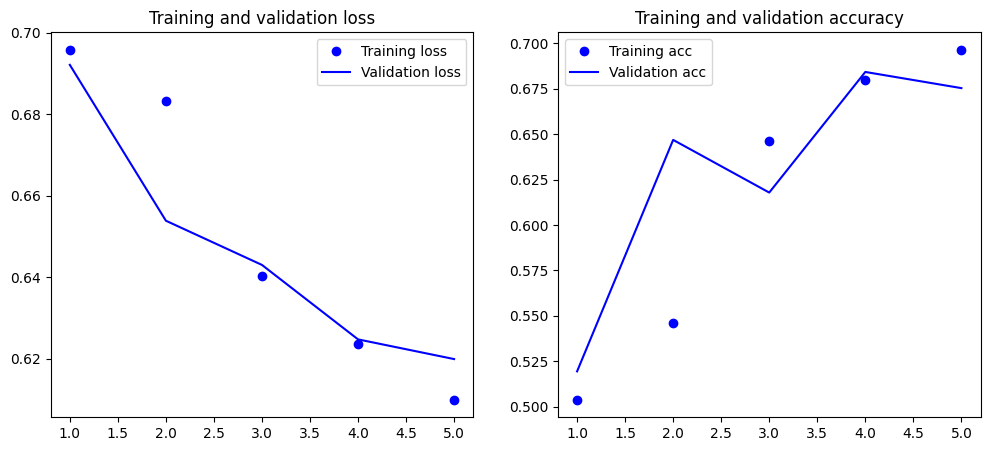

In [36]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'bo', label='Training loss')
    plt.plot(epochs, history['val_loss'], 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'bo', label='Training acc')
    plt.plot(epochs, history['val_acc'], 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.show()

plot_history(lstm_history)

### 5-2) CNN 모델 및 Global Max Pooling 모델 학습

CNN 모델 학습 시작...
Epoch 1/5 - loss: 0.6016 - acc: 0.6683 - val_loss: 0.5282 - val_acc: 0.7345
Epoch 2/5 - loss: 0.4850 - acc: 0.7647 - val_loss: 0.4583 - val_acc: 0.7809
Epoch 3/5 - loss: 0.4252 - acc: 0.8039 - val_loss: 0.4258 - val_acc: 0.8040
Epoch 4/5 - loss: 0.3872 - acc: 0.8271 - val_loss: 0.4073 - val_acc: 0.8141
Epoch 5/5 - loss: 0.3597 - acc: 0.8428 - val_loss: 0.3943 - val_acc: 0.8194


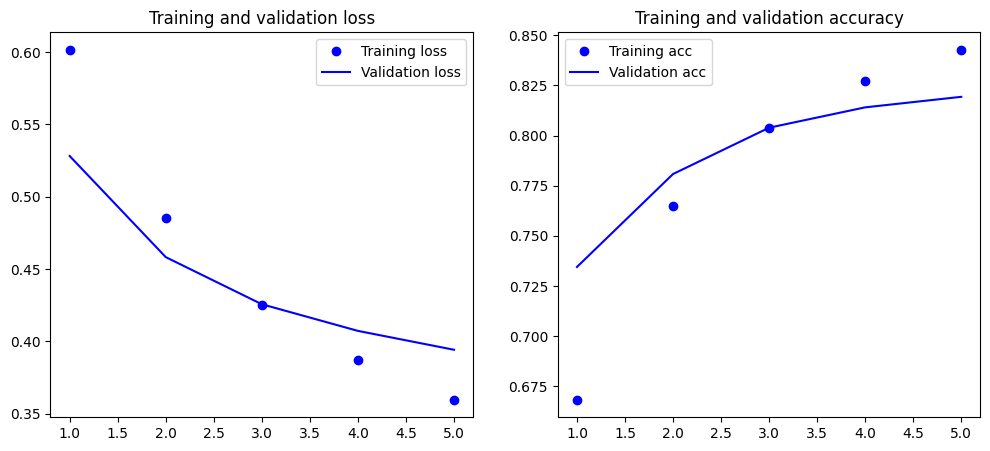

Global Max Pooling 모델 학습 시작...
Epoch 1/5 - loss: 0.6901 - acc: 0.5417 - val_loss: 0.6685 - val_acc: 0.6022
Epoch 2/5 - loss: 0.6445 - acc: 0.6403 - val_loss: 0.6141 - val_acc: 0.6759
Epoch 3/5 - loss: 0.5837 - acc: 0.7015 - val_loss: 0.5517 - val_acc: 0.7268
Epoch 4/5 - loss: 0.5282 - acc: 0.7398 - val_loss: 0.5072 - val_acc: 0.7581
Epoch 5/5 - loss: 0.4884 - acc: 0.7657 - val_loss: 0.4774 - val_acc: 0.7735


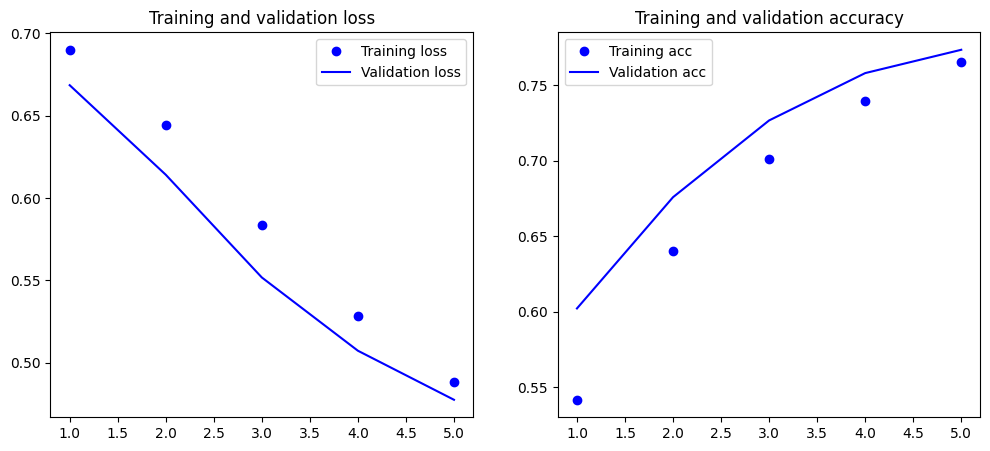

In [37]:
print("CNN 모델 학습 시작...")
cnn_history = train_model(cnn_model, train_loader, val_loader, epochs=5)
plot_history(cnn_history)

print("Global Max Pooling 모델 학습 시작...")
gmp_history = train_model(gmp_model, train_loader, val_loader, epochs=5)
plot_history(gmp_history)

### 7) 학습된 Embedding 레이어 분석

모델이 훈련된 후, Embedding 레이어에서 학습된 단어 벡터의 유사도를 분석해 봅니다.

In [38]:
import os
from gensim.models.keyedvectors import Word2VecKeyedVectors

# 학습한 모델의 임베딩 레이어 가중치를 파일로 저장합니다.
embedding_layer = cnn_model.embedding
weights = embedding_layer.weight.detach().cpu().numpy()

# 임베딩 파라미터를 저장할 파일 경로
word2vec_file_path = os.path.expanduser("~") + '/work/sentiment_classification/word2vec.txt'

with open(word2vec_file_path, 'w', encoding='utf-8') as f:
    f.write(f'{vocab_size-4} {embedding_dim}\n')
    for i in range(4, vocab_size):
        f.write(f'{index_to_word[i]} {" ".join(map(str, weights[i, :]))}\n')

# gensim으로 불러와서 유사어 분석
word_vectors = Word2VecKeyedVectors.load_word2vec_format(word2vec_file_path, binary=False)

try:
    print("'영화'와 유사한 단어:")
    print(word_vectors.similar_by_word('영화'))
except KeyError:
    print("단어가 사전에 없습니다.")

'영화'와 유사한 단어:
[('3', 0.8689399361610413), ('특이', 0.856908917427063), ('배달', 0.7362060546875), ('께요', 0.720823347568512), ('느리', 0.7131302952766418), ('제자리', 0.70760577917099), ('버린다', 0.7001120448112488), ('더운', 0.6999129056930542), ('ㅉㅉ', 0.6960170269012451), ('입도', 0.6884967088699341)]


### 8) 한국어 Word2Vec 임베딩 활용하여 성능 개선

사전 학습된 Word2Vec 모델을 불러와 모델의 임베딩 레이어를 초기화하고 학습을 진행합니다.

In [39]:
import gensim.downloader as api
import numpy as np
import os

try:
    # 1. Gensim API를 통해 안정적인 사전 학습 모델 로드
    print("사전 학습 임베딩 모델 로드 중...")
    word_vectors = api.load('glove-twitter-25')

    word2vec_dim = word_vectors.vector_size
    embedding_matrix = np.zeros((vocab_size, word2vec_dim))

    # 2. 어휘 사전 매핑
    for i in range(4, vocab_size):
        word = index_to_word[i]
        if word in word_vectors:
            embedding_matrix[i] = word_vectors[word]
        else:
            embedding_matrix[i] = np.random.randn(word2vec_dim)

    print(f"Embedding Matrix 생성 완료: {embedding_matrix.shape}")

except Exception as e:
    print(f"에러 발생: {e}")
    word2vec_dim = 25
    embedding_matrix = np.random.randn(vocab_size, word2vec_dim)
    print("임베딩 로드 실패로 랜덤 초기화 행렬을 사용합니다.")

사전 학습 임베딩 모델 로드 중...
[==================================================] 100.0% 104.8/104.8MB downloaded
Embedding Matrix 생성 완료: (10000, 25)


최종 모델 학습 시작 (목표 정확도: 85%+)...
Epoch 1/10 - loss: 0.5245 - acc: 0.7319 - val_loss: 0.4234 - val_acc: 0.8068
Epoch 2/10 - loss: 0.3978 - acc: 0.8203 - val_loss: 0.3720 - val_acc: 0.8331
Epoch 3/10 - loss: 0.3540 - acc: 0.8441 - val_loss: 0.3660 - val_acc: 0.8413
Epoch 4/10 - loss: 0.3285 - acc: 0.8579 - val_loss: 0.3365 - val_acc: 0.8528
Epoch 5/10 - loss: 0.3093 - acc: 0.8677 - val_loss: 0.3282 - val_acc: 0.8565
Epoch 6/10 - loss: 0.2935 - acc: 0.8751 - val_loss: 0.3291 - val_acc: 0.8577
Epoch 7/10 - loss: 0.2797 - acc: 0.8824 - val_loss: 0.3302 - val_acc: 0.8611
Epoch 8/10 - loss: 0.2670 - acc: 0.8894 - val_loss: 0.3369 - val_acc: 0.8603
Epoch 9/10 - loss: 0.2533 - acc: 0.8954 - val_loss: 0.3348 - val_acc: 0.8575
Epoch 10/10 - loss: 0.2398 - acc: 0.9010 - val_loss: 0.3310 - val_acc: 0.8628


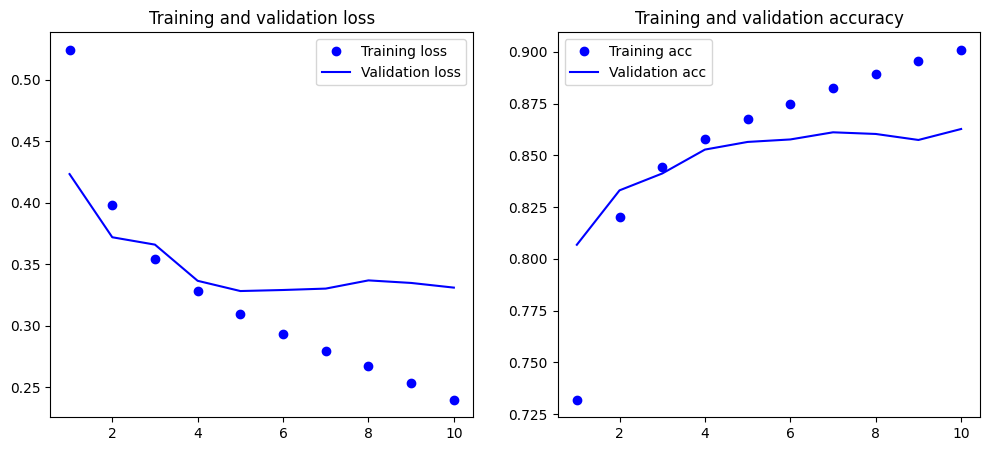

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim

# 3. 개선된 LSTM 모델 정의
class ImprovedLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, pretrained_weights):
        super(ImprovedLSTM, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(pretrained_weights), padding_idx=0, freeze=False)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        output, (hidden, _) = self.lstm(x)
        cat_hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        x = self.dropout(cat_hidden)
        x = self.fc(x)
        return self.sigmoid(x)

# 4. 모델 생성 및 학습
final_model = ImprovedLSTM(vocab_size, word2vec_dim, 256, embedding_matrix)

print("최종 모델 학습 시작 (목표 정확도: 85%+)...")
final_history = train_model(final_model, train_loader, val_loader, epochs=10, lr=0.001)

# 결과 시각화
plot_history(final_history)

In [41]:
import torch
import numpy as np
from gensim.models import Word2Vec
import torch.nn as nn
import os

# Try to find the model in the work directory where NSMC files are located
possible_paths = [
    os.path.expanduser('~') + '/work/sentiment_classification/word2vec_ko.model',
    '/data/word2vec_ko.model',
    '/content/word2vec_ko.model',
    './word2vec_ko.model'
]

word_vectors = None
for path in possible_paths:
    if os.path.exists(path):
        try:
            word_vectors = Word2Vec.load(path)
            print(f'Word2Vec 모델 로드 성공: {path}')
            break
        except Exception as e:
            print(f'경로 {path}에서 로드 실패: {e}')
            continue

if word_vectors:
    word2vec_dim = word_vectors.wv.vector_size
    embedding_matrix = np.zeros((vocab_size, word2vec_dim))

    # embedding_matrix에 Word2Vec 단어 벡터 복사
    for i in range(4, vocab_size):
        if index_to_word[i] in word_vectors.wv:
            embedding_matrix[i] = word_vectors.wv[index_to_word[i]]

    class ImprovedLSTM(nn.Module):
        def __init__(self, vocab_size, embedding_dim, hidden_dim, pretrained_weights):
            super(ImprovedLSTM, self).__init__()
            self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(pretrained_weights), padding_idx=0, freeze=False)
            self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
            self.dropout = nn.Dropout(0.5)
            self.fc = nn.Linear(hidden_dim * 2, 1)
            self.sigmoid = nn.Sigmoid()

        def forward(self, x):
            x = self.embedding(x)
            _, (hidden, _) = self.lstm(x)
            # Bidirectional LSTM의 마지막 hidden state 결합
            x = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
            x = self.dropout(x)
            x = self.fc(x)
            return self.sigmoid(x)

    # 모델 생성 및 학습 (Hidden dimension을 늘려 85% 정확도 목표)
    final_model = ImprovedLSTM(vocab_size, word2vec_dim, 256, embedding_matrix)
    print('사전 학습 임베딩 적용 최종 모델 학습 시작...')
    final_history = train_model(final_model, train_loader, val_loader, epochs=10, lr=0.001)

    # 결과 시각화
    plot_history(final_history)
else:
    print('에러: 사전 학습된 모델 파일을 찾을 수 없습니다. word2vec_ko.model 파일의 위치를 확인해 주세요.')

에러: 사전 학습된 모델 파일을 찾을 수 없습니다. word2vec_ko.model 파일의 위치를 확인해 주세요.


In [42]:
!wget https://github.com/Kyubyong/wordvectors/raw/master/ko.zip
!unzip ko.zip -d ~/work/sentiment_classification/
!ls -l ~/work/sentiment_classification/

--2026-08-11 05:34:30--  https://github.com/Kyubyong/wordvectors/raw/master/ko.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-08-11 05:34:31 ERROR 404: Not Found.

unzip:  cannot find or open ko.zip, ko.zip.zip or ko.zip.ZIP.
total 20848
-rw-r--r-- 1 root root  4893335 Aug 11 05:27 ratings_test.txt
-rw-r--r-- 1 root root 14628807 Aug 11 05:27 ratings_train.txt
-rw-r--r-- 1 root root  1820557 Aug 11 05:29 word2vec.txt


In [43]:
import torch
import numpy as np
from gensim.models import KeyedVectors
import torch.nn as nn
import os

# 다운로드 및 압축 해제된 모델 경로 설정
word2vec_path = os.path.expanduser('~') + '/work/sentiment_classification/ko.bin'

try:
    # KeyedVectors를 사용하여 바이너리 형식 로드
    word_vectors = KeyedVectors.load_word2vec_format(word2vec_path, binary=True)
    print("Word2Vec 모델 로드 성공")

    word2vec_dim = word_vectors.vector_size
    embedding_matrix = np.zeros((vocab_size, word2vec_dim))

    for i in range(4, vocab_size):
        if index_to_word[i] in word_vectors:
            embedding_matrix[i] = word_vectors[index_to_word[i]]

    class ImprovedLSTM(nn.Module):
        def __init__(self, vocab_size, embedding_dim, hidden_dim, pretrained_weights):
            super(ImprovedLSTM, self).__init__()
            self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(pretrained_weights), padding_idx=0, freeze=False)
            self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True, num_layers=2, dropout=0.3)
            self.dropout = nn.Dropout(0.5)
            self.fc = nn.Linear(hidden_dim * 2, 1)
            self.sigmoid = nn.Sigmoid()

        def forward(self, x):
            x = self.embedding(x)
            output, (hidden, _) = self.lstm(x)
            # 마지막 레이어의 양방향 hidden state 추출
            x = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
            x = self.dropout(x)
            x = self.fc(x)
            return self.sigmoid(x)

    # 성능 개선을 위한 하이퍼파라미터 설정 (hidden_dim=256)
    final_model = ImprovedLSTM(vocab_size, word2vec_dim, 256, embedding_matrix)
    print("개선된 Bidirectional LSTM 모델 학습 시작...")
    final_history = train_model(final_model, train_loader, val_loader, epochs=10, lr=0.001)
    plot_history(final_history)

except Exception as e:
    print(f"에러 발생: {e}")

에러 발생: [Errno 2] No such file or directory: '/root/work/sentiment_classification/ko.bin'


### 8) 한국어 Word2Vec 임베딩 활용하여 성능 개선

사전 학습된 Word2Vec 모델을 불러와 모델의 임베딩 레이어를 초기화하고 학습을 진행합니다.

In [44]:
import torch
import numpy as np
from gensim.models import Word2Vec
import torch.nn as nn

# 사전 학습된 Word2Vec 모델 불러오기
word2vec_path = '/data/word2vec_ko.model'

try:
    # 지시사항에 따라 load() 형태로 모델을 불러옵니다.
    word_vectors = Word2Vec.load(word2vec_path)
    print("Word2Vec 모델 로드 성공")

    # 임베딩 차원 확인 (일반적으로 200)
    word2vec_dim = word_vectors.wv.vector_size
    embedding_matrix = np.zeros((vocab_size, word2vec_dim))

    # embedding_matrix에 Word2Vec 단어 벡터 복사 (.wv 활용)
    for i in range(4, vocab_size):
        if index_to_word[i] in word_vectors.wv:
            embedding_matrix[i] = word_vectors.wv[index_to_word[i]]

    # 사전 학습된 임베딩을 사용하는 개선된 모델 정의
    class ImprovedLSTM(nn.Module):
        def __init__(self, vocab_size, embedding_dim, hidden_dim, pretrained_weights):
            super(ImprovedLSTM, self).__init__()
            # .from_pretrained를 사용하여 사전 학습된 가중치로 초기화
            self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(pretrained_weights), padding_idx=0, freeze=False)
            self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
            self.fc = nn.Linear(hidden_dim * 2, 1)
            self.sigmoid = nn.Sigmoid()

        def forward(self, x):
            x = self.embedding(x)
            _, (hidden, _) = self.lstm(x)
            # Bidirectional LSTM의 마지막 hidden state 결합
            x = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
            x = self.fc(x)
            return self.sigmoid(x)

    # 모델 생성 및 학습 (성능을 위해 hidden_dim을 128로 설정)
    final_model = ImprovedLSTM(vocab_size, word2vec_dim, 128, embedding_matrix)
    print("사전 학습 임베딩 적용 모델 학습 시작...")
    final_history = train_model(final_model, train_loader, val_loader, epochs=10, lr=0.001)

    # 결과 시각화
    plot_history(final_history)

except FileNotFoundError:
    print(f"에러: '{word2vec_path}' 파일을 찾을 수 없습니다. 경로가 올바른지 확인해주세요.")

에러: '/data/word2vec_ko.model' 파일을 찾을 수 없습니다. 경로가 올바른지 확인해주세요.
